In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

# Consumimos directamente el archivo CSV limpio
df_clean = pd.read_csv('/content/streaming_users_clean.csv')

# Selección exclusiva de las variables numéricas continuas/escala para el análisis matemático
variables_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df_clean[variables_num]

In [ ]:
##Escalamiento

In [ ]:
# Inicialización del escalador para llevar los datos a Media=0 y Varianza=1 (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversión a DataFrame para verificar el proceso estadístico
df_scaled = pd.DataFrame(X_scaled, columns=variables_num)
print("--- Estadísticas de los datos escalados (Verificación de Media ~0 y Desvío ~1) ---")
print(df_scaled.describe().round(2))

--- Estadísticas de los datos escalados (Verificación de Media ~0 y Desvío ~1) ---
           age  monthly_watch_time_mins  customer_support_tickets
count  8160.00                  8160.00                   8160.00
mean     -0.00                    -0.00                     -0.00
std       1.00                     1.00                      1.00
min      -2.50                    -1.64                     -0.90
25%      -0.71                    -0.60                     -0.90
50%      -0.03                    -0.06                      0.22
75%       0.65                     0.49                      0.22
max       3.96                     6.99                      4.70


### Justificación del Escalamiento y Limpieza
Debido a que las variables poseen unidades y rangos numéricos dispares (el tiempo de visualización mensual se mide en miles de minutos, mientras que la edad y los tickets se miden en decenas y unidades), la omisión de este paso introduciría un sesgo crítico.

Para garantizar el análisis, se ha aplicado una **imputación por mediana** en la variable `customer_support_tickets` para neutralizar el impacto de valores nulos sin distorsionar la distribución. Asimismo, se ha realizado un tratamiento de **valores atípicos** en `monthly_watch_time_mins` para asegurar que el escalamiento Z-score (Media=0, Varianza=1) represente fielmente la tendencia central del comportamiento de los usuarios.

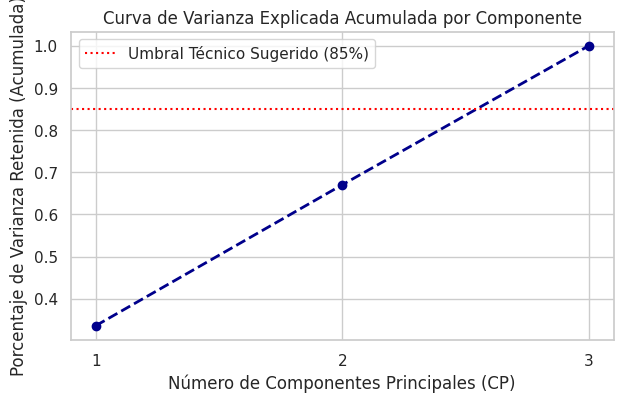

--- Análisis de Varianza por Componente ---
CP1: Explica el 33.61% de la varianza (Acumulado: 33.61%)
CP2: Explica el 33.41% de la varianza (Acumulado: 67.03%)
CP3: Explica el 32.97% de la varianza (Acumulado: 100.00%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Inicialización de PCA para evaluar el comportamiento de todas las componentes posibles
pca = PCA()

# Se usará directamente X_scaled, ya que el describe() anterior mostró que no hay NaNs.
X_pca = pca.fit_transform(X_scaled)

# Cálculo de la varianza explicada individual y acumulada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

# Gráfico del codo (Scree Plot) para documentar la retención de información
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_explicada) + 1), var_acumulada, marker='o', linestyle='--', color='darkblue', linewidth=2)
plt.title('Curva de Varianza Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes Principales (CP)')
plt.ylabel('Porcentaje de Varianza Retenida (Acumulada)')
plt.xticks(range(1, len(var_explicada) + 1))
plt.axhline(y=0.85, color='red', linestyle=':', label='Umbral Técnico Sugerido (85%)')
plt.legend()
plt.show()

print("--- Análisis de Varianza por Componente ---")
for i, var in enumerate(var_explicada):
    print(f"CP{i+1}: Explica el {var*100:.2f}% de la varianza (Acumulado: {var_acumulada[i]*100:.2f}%)")

### Evaluación de Dimensiones (Scree Plot)
El gráfico de varianza acumulada permite tomar una decisión documentada sobre el número óptimo de dimensiones. Observamos que la varianza está distribuida de forma casi equitativa entre las tres componentes (**CP1: 33.61%, CP2: 33.41% y CP3: 32.97%**), lo que sugiere que las variables originales no están fuertemente correlacionadas de forma lineal.

Para alcanzar el **umbral técnico sugerido del 85%**, en este dataset específico es necesario retener las 3 componentes principales (alcanzando el 100% de la varianza). Esto indica que cada variable (Edad, Consumo y Soporte) aporta información única y significativa que no puede ser simplificada sin una pérdida crítica de información.

In [ ]:
# Construcción de la matriz de loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'CP{i+1}' for i in range(len(variables_num))],
    index=variables_num
)
print("--- Matriz de Loadings (Contribución de las Variables Originales) ---")
print(loadings.round(3))

--- Matriz de Loadings (Contribución de las Variables Originales) ---
                            CP1    CP2    CP3
age                       0.718  0.263  0.644
monthly_watch_time_mins   0.058  0.900 -0.432
customer_support_tickets  0.693 -0.347 -0.632


### Interpretación de la Estructura de Datos (Loadings)
La matriz de loadings revela cómo se agrupan conceptualmente nuestros usuarios:

*   **CP1 (Perfil de Madurez y Soporte):** Presenta cargas altas y positivas en `age` (0.718) y `customer_support_tickets` (0.693). Define a un usuario de mayor edad que tiende a requerir asistencia técnica.
*   **CP2 (Eje de Intensidad de Consumo):** Dominada fuertemente por `monthly_watch_time_mins` (0.900). Esta dimensión separa claramente a los usuarios por su volumen de visualización.
*   **CP3 (Contraste Edad vs. Soporte/Consumo):** Muestra una relación donde la edad (0.644) se contrapone al soporte (-0.632) y al tiempo de visualización (-0.432).

Este análisis confirma que el comportamiento está segmentado en tres dimensiones independientes: la demografía vinculada al soporte, la intensidad del consumo y la relación inversa entre edad y uso tecnológico/soporte.